# GHGRP: what the data looks like, 2010–2023
**Yiling Long · 28 July 2026**

---

US environmental regulation contains a provision that lets a facility stop disclosing its
emissions once it has stayed small for long enough. This notebook is a first look at whether
firms use it, and at what that behaviour reveals about the private cost of public disclosure.

It is written up in the order I ran it, and it keeps the sequence honest: what I looked at,
what surprised me, and how each picture changed what I looked at next. Two of the three
things I expected to find are not there. The one that survived is not the one I set out to
test.

**Scope.** The full public GHGRP panel: 94,378 facility-years, 8,778 facilities, 2010–2023.
Nothing below requires a merge with firm-level data — this is all EPA's own facility-level
release, reproducible from the public download.

**Institutional background.** The Greenhouse Gas Reporting Program (40 CFR Part 98) requires
facilities emitting ≥25,000 tCO₂e per year to report, and EPA publishes the reports facility
by facility. Less well known is **40 CFR 98.2(i)**, which lets a facility already in the
program stop reporting after *five consecutive years below 25,000* or *three consecutive
years below 15,000*, on notifying EPA — and requires it to resume if emissions ever reach
25,000 again. That provision turns out to do most of the work here, so I flag it at the start.

---
### Setup

In [12]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
warnings.filterwarnings("ignore")
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi":110, "axes.grid":True, "grid.alpha":.25,
                     "axes.spines.top":False, "axes.spines.right":False})

sys.path.insert(0, ".")
from ghgrp_load import load_ghgrp, add_eligibility, ALWAYS_COVERED, ALWAYS_COVERED_STRICT

OUT = Path("output"); OUT.mkdir(exist_ok=True)
de  = load_ghgrp()
de  = add_eligibility(de)

# policy events for the timeline overlays (verify the unconfirmed ones -- see the guide)
EVENTS = {2015:"CPP finalized", 2016:"SCOTUS stay", 2017:"Paris announcement",
          2019:"ACE repeals CPP", 2020:"Paris exit effective", 2021:"US rejoins"}
def mark(ax, ymax=None):
    for y,lab in EVENTS.items():
        if de.year.min() <= y <= de.year.max():
            ax.axvline(y, color="gray", ls=":", lw=.9, zorder=0)

  2010   6,297 facilities   (ghgp_data_2010.xlsx)
  2011   6,907 facilities   (ghgp_data_2011.xlsx)
  2012   7,102 facilities   (ghgp_data_2012.xlsx)
  2013   7,191 facilities   (ghgp_data_2013.xlsx)
  2014   7,349 facilities   (ghgp_data_2014.xlsx)
  2015   7,242 facilities   (ghgp_data_2015.xlsx)
  2016   6,572 facilities   (ghgp_data_2016.xlsx)
  2017   6,488 facilities   (ghgp_data_2017.xlsx)
  2018   6,581 facilities   (ghgp_data_2018.xlsx)
  2019   6,580 facilities   (ghgp_data_2019.xlsx)
  2020   6,556 facilities   (ghgp_data_2020.xlsx)
  2021   6,529 facilities   (ghgp_data_2021.xlsx)
  2022   6,514 facilities   (ghgp_data_2022.xlsx)
  2023   6,470 facilities   (ghgp_data_2023.xlsx)

94,378 facility-years | 8,778 facilities | 2010-2023
always-covered share: 36.8% (strict D/F/G/H only: 19.4%)
CEMS facilities: 4.2%
eligible facility-years: 4,755 (5.0%)
facilities ever eligible: 1,696 (19.3%)
exit rate | eligible: 0.209   | not eligible: 0.015


---
## 1 · Panel structure and timeline

In [13]:
tab = (de.groupby("year")
         .agg(facilities   = ("FacilityId","nunique"),
              entries      = ("enters","sum"),
              exits        = ("exits","sum"),
              total_Mt     = ("emissions", lambda s: s.sum()/1e6),
              median_em    = ("emissions","median"),
              share_lt25k  = ("emissions", lambda s: (s<25000).mean()),
              share_lt15k  = ("emissions", lambda s: (s<15000).mean()))
         .round(3))
display(tab)
tab.to_csv(OUT/"t1_panel_by_year.csv")

print("\nyears observed per facility:")
display(de.groupby("FacilityId").year.nunique().value_counts().sort_index().to_frame("facilities").T)
print(f"\nbalanced (all {de.year.nunique()} years): "
      f"{(de.groupby('FacilityId').year.nunique()==de.year.nunique()).mean():.1%} of facilities")
print(f"facilities with a gap (left and came back): {de.groupby('FacilityId').gap_after.any().mean():.1%}")

,facilities,entries,exits,total_Mt,median_em,share_lt25k,share_lt15k
year,,,,,,,
2010,6297,0,41,3196.572,70075.000,0.121,0.085
2011,6907,668,32,3207.583,67478.298,0.140,0.087
2012,7102,225,130,3058.076,63556.011,0.163,0.094
2013,7191,232,113,3073.214,60206.424,0.181,0.102
2014,7349,259,257,3084.069,57855.192,0.188,0.110
2015,7242,171,756,2939.444,58465.660,0.180,0.094
2016,6572,115,191,2804.145,65538.309,0.160,0.082
2017,6488,132,92,2734.723,65455.004,0.158,0.081
2018,6581,159,158,2778.824,67984.244,0.145,0.071



years observed per facility:


year,1,2,3,4,5,6,7,8,9,10,11,12,13,14
facilities,202,240,324,298,480,620,279,235,227,246,269,227,441,4690



balanced (all 14 years): 53.4% of facilities
facilities with a gap (left and came back): 2.4%


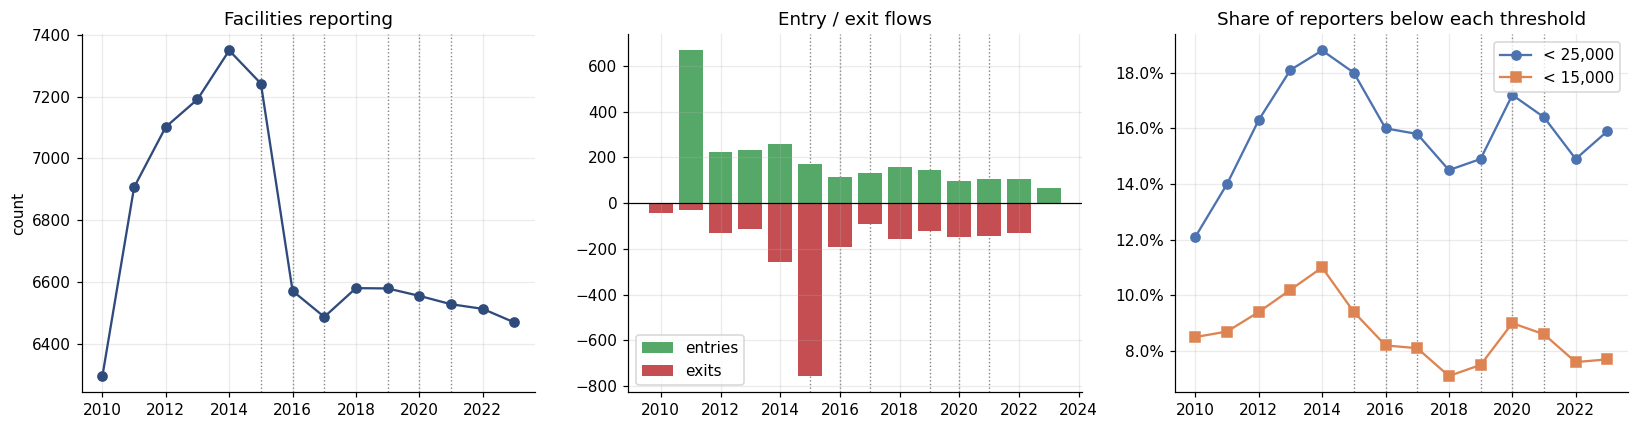

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))

ax[0].plot(tab.index, tab.facilities, "o-", color="#2F4B7C"); mark(ax[0])
ax[0].set_title("Facilities reporting"); ax[0].set_ylabel("count")

ax[1].bar(tab.index, tab.entries, color="#55A868", label="entries")
ax[1].bar(tab.index, -tab.exits,  color="#C44E52", label="exits")
ax[1].axhline(0, color="k", lw=.8); mark(ax[1]); ax[1].legend()
ax[1].set_title("Entry / exit flows")

ax[2].plot(tab.index, tab.share_lt25k, "o-", label="< 25,000", color="#4C72B0")
ax[2].plot(tab.index, tab.share_lt15k, "s-", label="< 15,000", color="#DD8452")
ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); mark(ax[2]); ax[2].legend()
ax[2].set_title("Share of reporters below each threshold")

plt.tight_layout(); plt.savefig(OUT/"f1_panel_structure.png", bbox_inches="tight"); plt.show()

**What I take from this**

The panel is not balanced — only a minority of facilities report in all fourteen years — and
there is meaningful entry and exit throughout. That is more movement than I expected from a
mandatory program, and it is the first hint that leaving the program is a common event rather
than a rarity.

The third panel is the one I care most about: it shows what share of reporters sit *below* each
threshold in each year. Facilities below 25,000 are not supposed to be in this data at all, so
whatever mass is there must be incumbents who dropped below the threshold and have not yet
left. That population is small but real, and it is the only place any threshold-based design
can live.

**One thing I flag immediately:** exits spike sharply in 2015. I come back to this in §5,
because my first instinct — that it was a rule change or an artefact of how I read the files —
turned out to be wrong, and the real explanation matters for everything else.

---
## 2 · Emissions distribution

,p10,p25,p50,p75,p90
year,,,,,
2010,19891.0,34584.0,70075.0,207922.0,979304.0
2011,18552.0,33365.0,67478.0,189573.0,887466.0
2012,16040.0,31763.0,63556.0,179247.0,851538.0
2013,14639.0,29811.0,60206.0,167373.0,828675.0
2014,13293.0,29181.0,57855.0,164355.0,823376.0
2015,16063.0,29949.0,58466.0,166845.0,823795.0
2016,17355.0,31793.0,65538.0,187041.0,894017.0
2017,18237.0,32613.0,65455.0,184295.0,866315.0
2018,20304.0,33348.0,67984.0,191822.0,902129.0


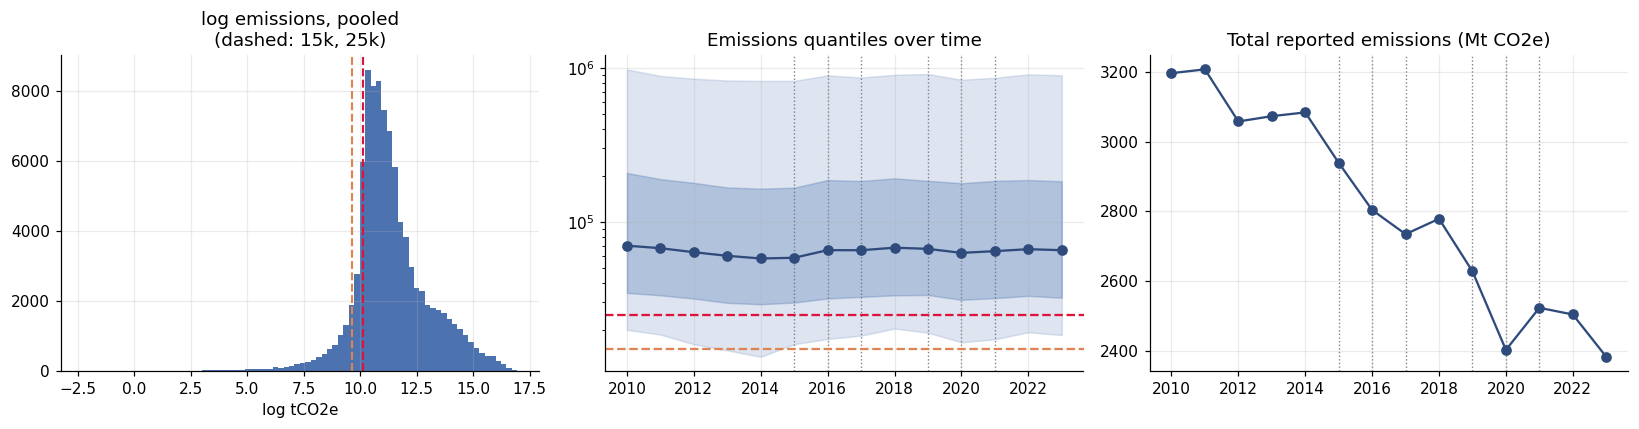

In [15]:
q = (de.groupby("year").emissions
       .quantile([.1,.25,.5,.75,.9]).unstack().round(0))
q.columns = [f"p{int(c*100)}" for c in q.columns]
display(q)

fig, ax = plt.subplots(1,3, figsize=(15,4))

ax[0].hist(de.log_em.dropna(), bins=80, color="#4C72B0")
for t,c in [(15000,"#DD8452"),(25000,"crimson")]:
    ax[0].axvline(np.log(t), color=c, ls="--", lw=1.4)
ax[0].set_title("log emissions, pooled\n(dashed: 15k, 25k)"); ax[0].set_xlabel("log tCO2e")

ax[1].fill_between(q.index, q.p10, q.p90, alpha=.18, color="#4C72B0")
ax[1].fill_between(q.index, q.p25, q.p75, alpha=.30, color="#4C72B0")
ax[1].plot(q.index, q.p50, "o-", color="#2F4B7C")
ax[1].axhline(25000, color="crimson", ls="--"); ax[1].axhline(15000, color="#DD8452", ls="--")
ax[1].set_yscale("log"); mark(ax[1]); ax[1].set_title("Emissions quantiles over time")

ax[2].plot(tab.index, tab.total_Mt, "o-", color="#2F4B7C"); mark(ax[2])
ax[2].set_title("Total reported emissions (Mt CO2e)")

plt.tight_layout(); plt.savefig(OUT/"f2_distribution.png", bbox_inches="tight"); plt.show()

**What I take from this**

The pooled log density is roughly log-normal with a hard left edge near log(25,000). That edge
is the reporting threshold truncating the sample, and it is worth sitting with for a moment,
because it rules out the design I came in wanting to run.

I had planned to look for bunching just below 25,000 — firms managing emissions down to escape
disclosure. **That is not identified here.** Facilities below the threshold do not report, so
the density below the cutoff is not the counterfactual density of a bunching design; it is a
selected sample of incumbents. A histogram at 25,000 shows a wall, and the wall is mechanical.

The quantile fan is flat over time, which is reassuring for a different reason: it means the
composition of the panel is not drifting so much that year-to-year comparisons are meaningless.

I also note here, without being able to settle it, that Tomar (2023, *JAR*) finds GHGRP
disclosure caused facilities to reduce emissions by 7.9% through peer benchmarking. If that is
operating, it pushes facilities *toward* the threshold for reasons that have nothing to do with
avoiding disclosure — which is a confound I will have to separate from any threshold story.

---
## 3 · The threshold region

The sniff test proper. I split the sample into two groups, which is the one piece of
institutional detail that does real work in this notebook:

- **Threshold-bound** facilities report only because they exceed 25,000 tCO₂e.
- **Always-covered** facilities — electricity generation, aluminum, ammonia, cement, and
  municipal landfills — must report *regardless of emissions*. Neither the 25,000 nor the
  15,000 threshold binds them.

The second group is a natural comparison: same industries, same firms, same years, but the rule
does not apply. If a feature of the density is caused by the threshold, it should show up in
the first group and not the second.

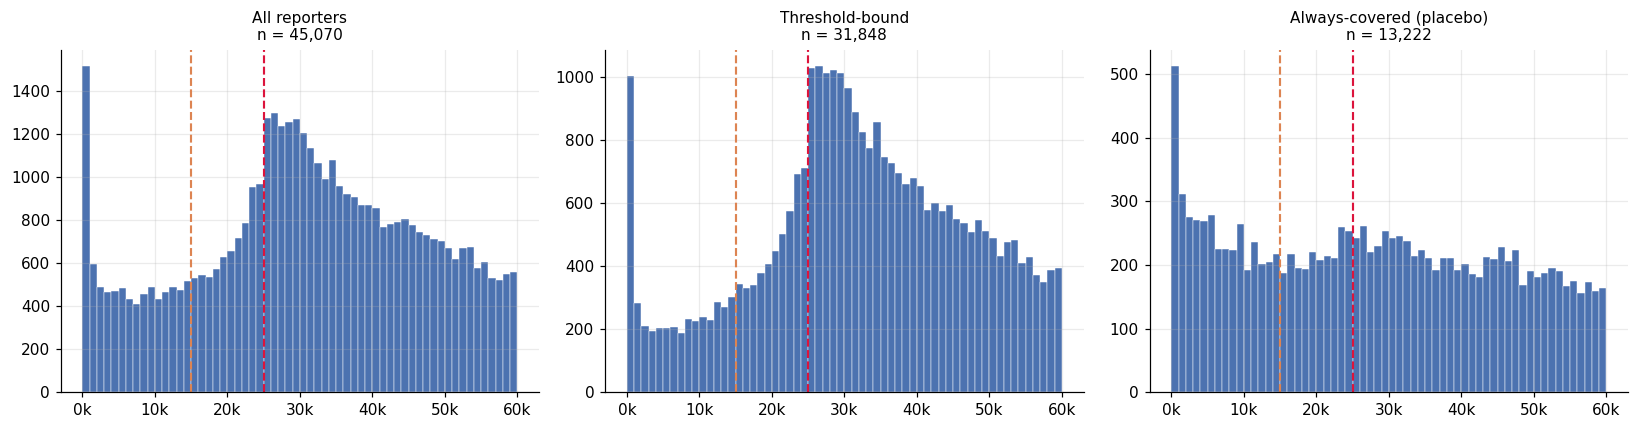

facility-years in the threshold region, by group:


threshold_bound,always-covered,threshold-bound
emissions,,
"(0, 10000]",2636,2678
"(10000, 15000]",1052,1331
"(15000, 20000]",1015,1801
"(20000, 25000]",1149,2928
"(25000, 30000]",1208,5120
"(30000, 50000]",4191,13486


In [16]:
def thr_hist(ax, d, lo, hi, bw, title):
    x = d.loc[d.emissions.between(lo,hi), "emissions"]
    ax.hist(x, bins=np.arange(lo, hi+bw, bw), color="#4C72B0", edgecolor="white", lw=.3)
    ax.axvline(25000, color="crimson", ls="--", lw=1.4)
    ax.axvline(15000, color="#DD8452", ls="--", lw=1.4)
    ax.set_title(f"{title}\nn = {len(x):,}", fontsize=10)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{v/1000:.0f}k"))

fig, ax = plt.subplots(1,3, figsize=(15,4))
thr_hist(ax[0], de,                        0, 60000, 1000, "All reporters")
thr_hist(ax[1], de[de.threshold_bound],    0, 60000, 1000, "Threshold-bound")
thr_hist(ax[2], de[de.always_covered],     0, 60000, 1000, "Always-covered (placebo)")
plt.tight_layout(); plt.savefig(OUT/"f3_threshold_region.png", bbox_inches="tight"); plt.show()

print("facility-years in the threshold region, by group:")
display(pd.crosstab(pd.cut(de.emissions, [0,10000,15000,20000,25000,30000,50000]),
                    de.threshold_bound.map({True:"threshold-bound", False:"always-covered"})))

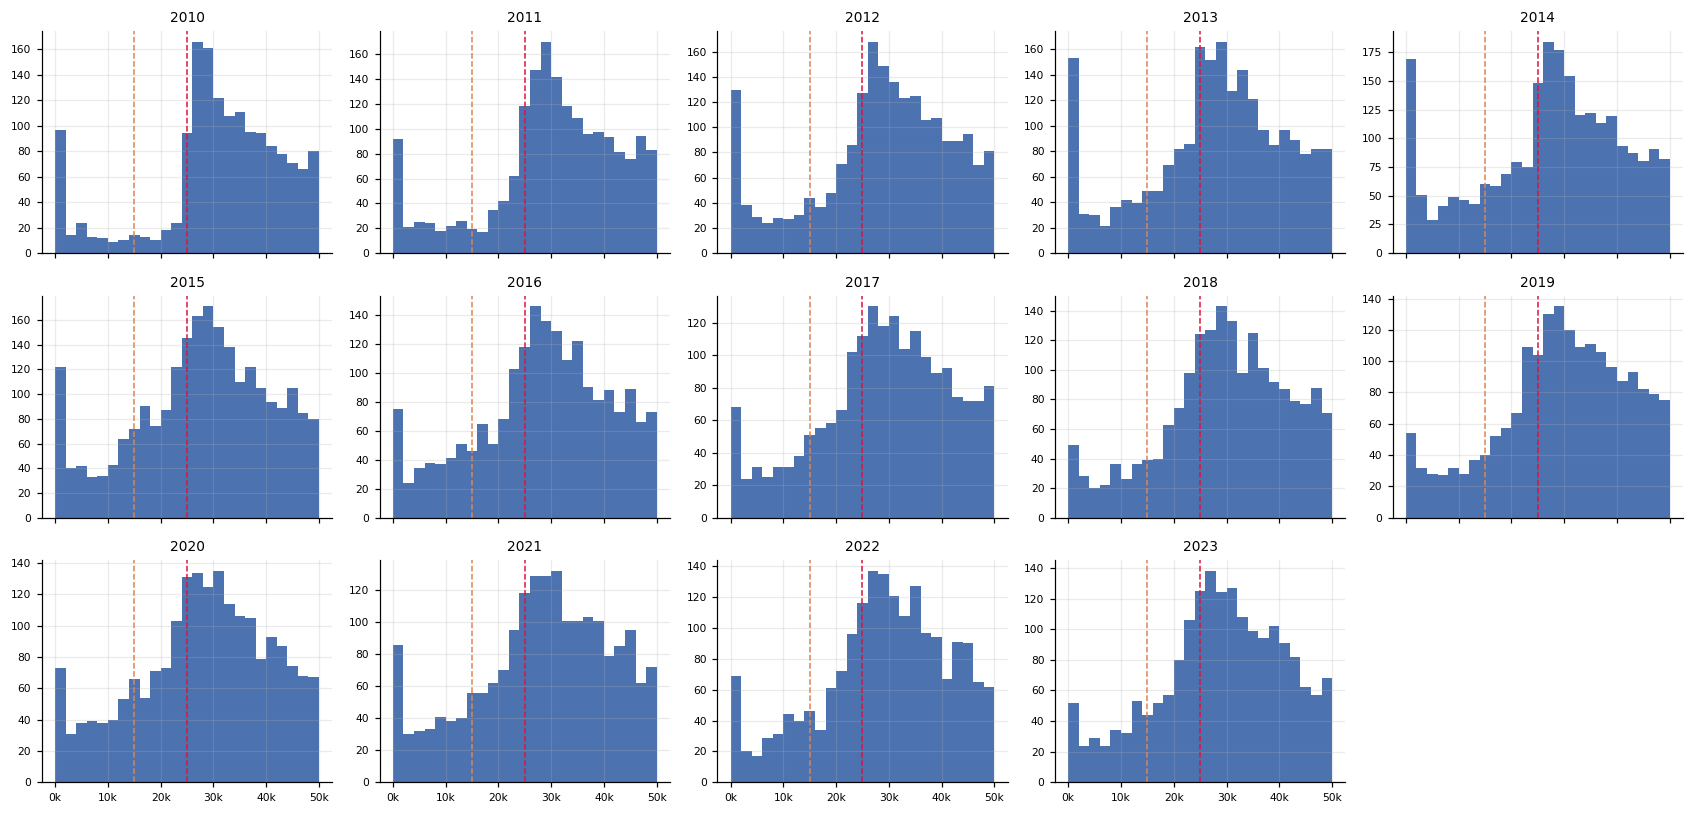

In [17]:
# same picture year by year -- does the shape move?
yrs = sorted(de.year.unique())
ncol = 5; nrow = int(np.ceil(len(yrs)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1*ncol, 2.5*nrow), sharex=True)
for a, y in zip(axes.ravel(), yrs):
    d = de[(de.year==y) & de.threshold_bound & de.emissions.between(0,50000)]
    a.hist(d.emissions, bins=np.arange(0,51000,2000), color="#4C72B0")
    a.axvline(25000, color="crimson", ls="--", lw=1); a.axvline(15000, color="#DD8452", ls="--", lw=1)
    a.set_title(y, fontsize=9); a.tick_params(labelsize=7)
    a.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{v/1000:.0f}k"))
for a in axes.ravel()[len(yrs):]: a.axis("off")
plt.tight_layout(); plt.savefig(OUT/"f4_threshold_by_year.png", bbox_inches="tight"); plt.show()

**What I take from this**

Two findings, one expected and one not.

**Expected:** the threshold-bound density has a sharp discontinuity at 25,000, and the
always-covered density runs smoothly through it. The truncation is real and it is caused by the
rule, not by anything about these industries. Good — but it also confirms that no bunching
estimate is available at 25,000.

**Not expected:** the density is *smooth through 15,000 as well.* I had hoped 15,000 would be a
clean interior notch — crossing it buys exit in three years instead of five, both sides are
observed, so the counterfactual density is estimable in the standard Chetty–Kleven way. There
is simply no visible excess mass there.

So the honest reading is that facilities are **not manipulating reported emissions** to reach
either off-ramp. That closes the density route. It does not close the question, because the
off-ramp is about *timing*, not levels — which is where §4 and §5 go.

---
## 4 · Entry and exit against emissions

If facilities are not manipulating emissions levels, the next question is whether they respond
on the exit margin — binning facilities by current emissions and taking departure from the
program as the outcome.

I also split on whether the facility uses **continuous emissions monitoring (CEMS)**. CEMS
facilities have instrument-measured emissions rather than self-reported ones, so they are much
harder to manipulate. EPA flags this directly in the annual files, which I had not expected to find there.

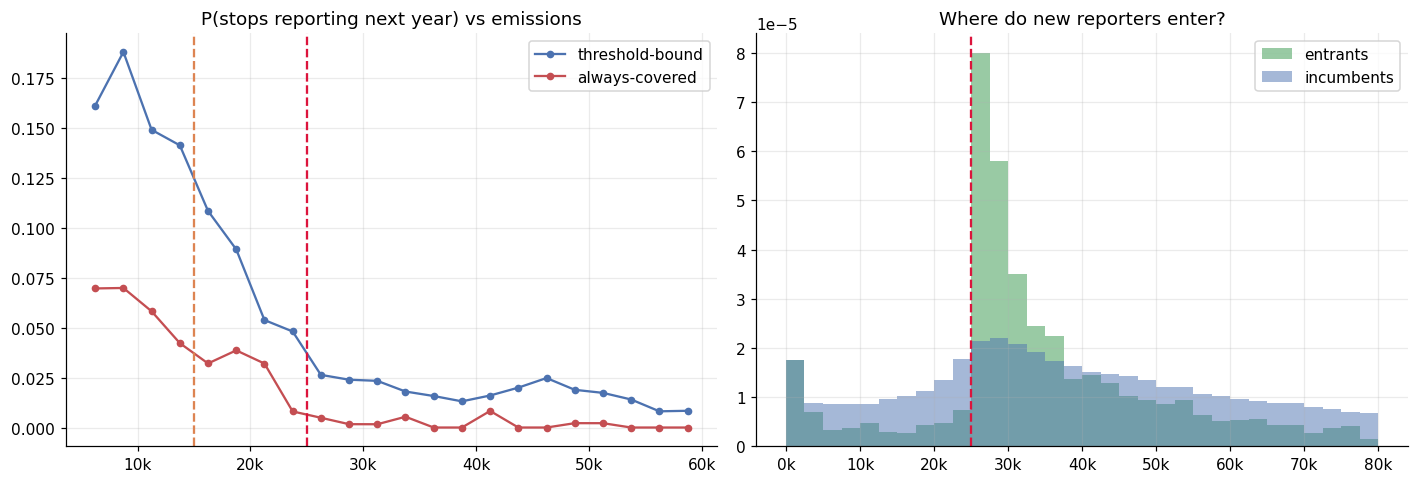

exit rate by eligibility status (40 CFR 98.2(i)):


,size,sum,mean
eligible,,,
False,89623,1312,0.0146
True,4755,996,0.2095


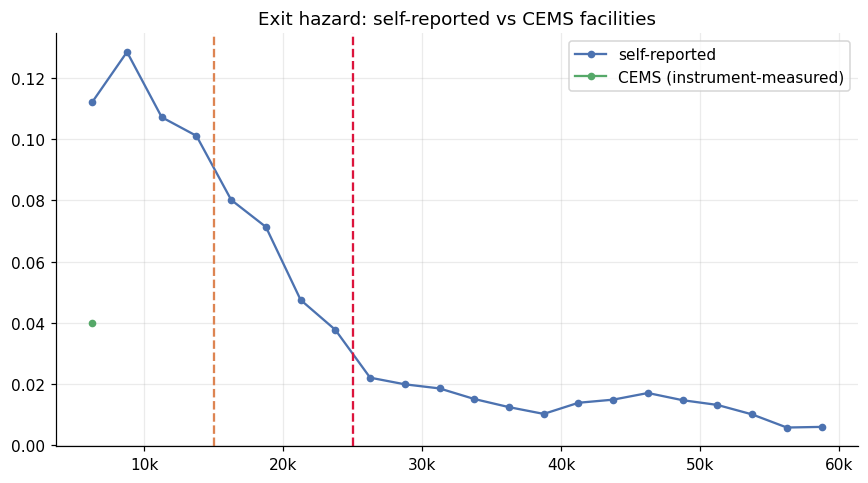

In [18]:
d = de[de.emissions.between(5000, 60000)].copy()
d["bin"] = pd.cut(d.emissions, np.arange(5000, 61000, 2500))
h = (d.groupby(["bin","threshold_bound"], observed=True)
       .agg(exit_rate=("exits","mean"), n=("exits","size")).reset_index())
h["mid"] = h["bin"].map(lambda i: i.mid)

fig, ax = plt.subplots(1,2, figsize=(13,4.5))
for tb, lab, c in [(True,"threshold-bound","#4C72B0"), (False,"always-covered","#C44E52")]:
    s = h[(h.threshold_bound==tb) & (h.n>=25)]
    ax[0].plot(s.mid, s.exit_rate, "o-", color=c, label=lab, ms=4)
ax[0].axvline(25000, color="crimson", ls="--"); ax[0].axvline(15000, color="#DD8452", ls="--")
ax[0].set_title("P(stops reporting next year) vs emissions"); ax[0].legend()
ax[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{v/1000:.0f}k"))

# entrants vs incumbents: where in the distribution do new reporters show up?
ax[1].hist(de.loc[de.enters & de.emissions.between(0,80000), "emissions"],
           bins=np.arange(0,81000,2500), density=True, alpha=.6, label="entrants", color="#55A868")
ax[1].hist(de.loc[~de.enters & de.emissions.between(0,80000), "emissions"],
           bins=np.arange(0,81000,2500), density=True, alpha=.5, label="incumbents", color="#4C72B0")
ax[1].axvline(25000, color="crimson", ls="--"); ax[1].legend()
ax[1].set_title("Where do new reporters enter?")
ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f"{v/1000:.0f}k"))
plt.tight_layout(); plt.savefig(OUT/"f5_entry_exit.png", bbox_inches="tight"); plt.show()

print("exit rate by eligibility status (40 CFR 98.2(i)):")
display(de.groupby("eligible").exits.agg(["size","sum","mean"]).round(4))

# --- CEMS split: manipulation vs real abatement ---
# CEMS facilities have instrument-measured emissions. If elevated exit / bunching shows up
# only among self-reporters, that is reporting manipulation rather than real abatement.
cm = (de[de.emissions.between(5000,60000)]
        .assign(bin=lambda d: pd.cut(d.emissions, np.arange(5000,61000,2500)))
        .groupby(["bin","cems"], observed=True)
        .agg(exit_rate=("exits","mean"), n=("exits","size")).reset_index())
cm["mid"]=cm["bin"].map(lambda i:i.mid)
fig, ax = plt.subplots(figsize=(8,4.5))
for v,lab,c_ in [(False,"self-reported","#4C72B0"),(True,"CEMS (instrument-measured)","#55A868")]:
    s_=cm[(cm.cems==v)&(cm.n>=25)]
    ax.plot(s_.mid, s_.exit_rate, "o-", color=c_, label=lab, ms=4)
ax.axvline(25000,color="crimson",ls="--"); ax.axvline(15000,color="#DD8452",ls="--")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_:f"{v/1000:.0f}k"))
ax.set_title("Exit hazard: self-reported vs CEMS facilities"); ax.legend()
plt.tight_layout(); plt.savefig(OUT/"f5b_cems.png", bbox_inches="tight"); plt.show()

**What I take from this**

The exit hazard rises steeply as emissions fall, and it rises far more for threshold-bound
facilities than for always-covered ones — from around 2.5% above the cutoff to nearly 19% at
the bottom of the range, against a much flatter profile for the comparison group. The two lines
separate below 25,000 and stay separated.

The entry panel is a nice mechanical validation that I did not plan: new reporters pile up
*just above* 25,000. That is exactly what the rule predicts — facilities join the program when
they cross the threshold from below — and it confirms the threshold is real and binding rather
than a data-processing artefact.

The eligibility table is the number that made me change direction. **Facility-years that are
eligible to leave under 98.2(i) end in exit 21.0% of the time; ineligible ones, 1.5%.**
That is 996 exits out of 4,755 eligible facility-years, so it is not a thin-tail curiosity.

Facilities are not managing their emissions around the threshold. They are managing *when they
leave*. Those are different behaviours and I had been looking for the wrong one.

---
## 5 · Within-facility dynamics — and the 2015 problem

Two things here. First, how emissions move within a facility from year to year, which
determines whether being below the threshold is an absorbing state or a transient one. Second,
the 2015 exit spike flagged in §1, which has to be explained before anything above can be trusted.

downward crossings of 25,000: 3,753


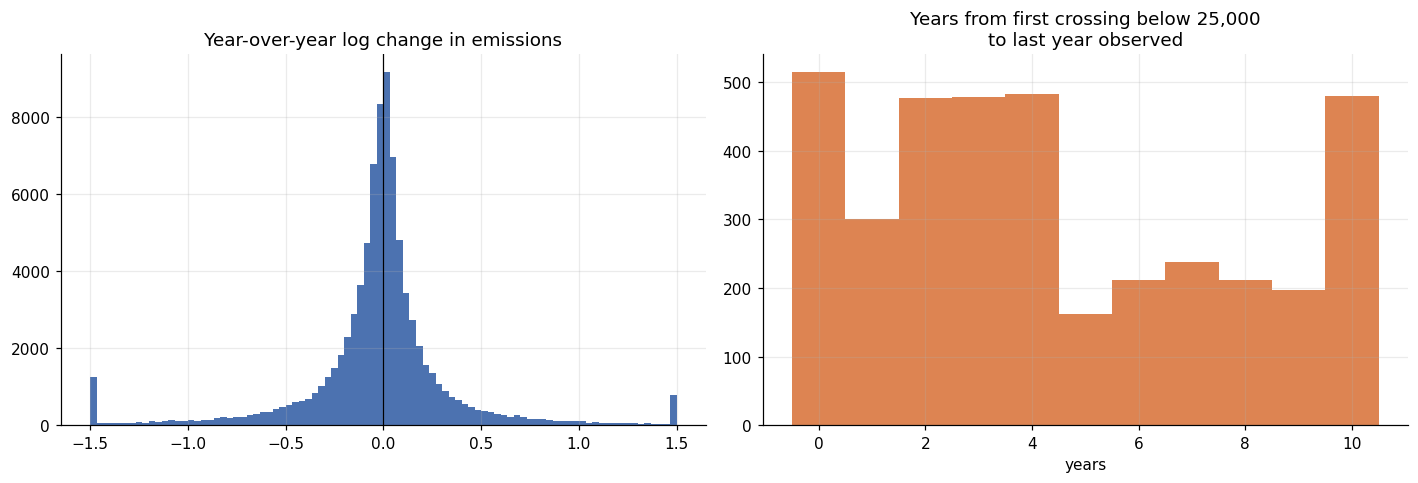


transition matrix across emission bins (t -> t+1), threshold-bound only:


emissions,<15k,15-25k,25-50k,>50k
lag_em,,,,
<15k,0.757,0.122,0.082,0.039
15-25k,0.168,0.572,0.237,0.022
25-50k,0.032,0.102,0.765,0.101
>50k,0.006,0.006,0.057,0.931


In [19]:
de = de.sort_values(["FacilityId","year"])
de["dlog"] = de.groupby("FacilityId").log_em.diff()
de["lag_em"] = de.groupby("FacilityId").emissions.shift(1)

fig, ax = plt.subplots(1,2, figsize=(13,4.5))
ax[0].hist(de.dlog.dropna().clip(-1.5,1.5), bins=90, color="#4C72B0")
ax[0].axvline(0, color="k", lw=.8)
ax[0].set_title("Year-over-year log change in emissions")

# do facilities that cross below 25,000 subsequently leave?
crossed = de[(de.lag_em >= 25000) & (de.emissions < 25000)]
print(f"downward crossings of 25,000: {len(crossed):,}")
fut = (de.merge(crossed[["FacilityId","year"]].assign(cross=1), on=["FacilityId","year"], how="left"))
surv = (crossed.merge(de.groupby("FacilityId").last_year.max().rename("lastY"),
                      on="FacilityId", how="left")
              .assign(years_until_exit=lambda d: d.lastY - d.year))
ax[1].hist(surv.years_until_exit.clip(0,10), bins=np.arange(-.5,11.5,1), color="#DD8452")
ax[1].set_title("Years from first crossing below 25,000\nto last year observed")
ax[1].set_xlabel("years")
plt.tight_layout(); plt.savefig(OUT/"f6_dynamics.png", bbox_inches="tight"); plt.show()

print("\ntransition matrix across emission bins (t -> t+1), threshold-bound only:")
bins = [0,15000,25000,50000,1e9]; labs = ["<15k","15-25k","25-50k",">50k"]
tb = de[de.threshold_bound].dropna(subset=["lag_em"])
display(pd.crosstab(pd.cut(tb.lag_em, bins, labels=labs),
                    pd.cut(tb.emissions, bins, labels=labs), normalize="index").round(3))

**What I take from this**

The transition matrix says the below-threshold state is persistent but not absorbing — facilities
that drop under 15,000 mostly stay there, but a meaningful share climb back above 25,000. That
matters, because it means exiting is a *choice* among facilities that could have stayed, rather
than the mechanical consequence of shutting down.

**On 2015.** There are 756 exits that year against 90–260 in a typical year. I worked through
three explanations:

1. *A bug in how I read the files.* EPA changed the workbook layout in 2016, splitting oil and
   gas segments into separate sheets, and my loader reads only the direct-emitters sheet — so
   facilities that merely moved sheets would look like exits. **Checked and ruled out:** only 4
   of the 756 appear anywhere in the 2016 workbook.
2. *A rule change.* EPA did finalise amendments effective 2016, but they revised methods and
   confidentiality determinations rather than removing this population from coverage.
3. *An economic shock.* Of the 756, 580 report under subpart C alone; the NAICS composition is
   oil and gas extraction (334), mining support (101), utilities (89), pipelines (84); the
   states are Texas, Arkansas, Oklahoma, Colorado, Wyoming; median emissions 24,409.

**It is the 2014–16 oil price collapse.** Production fell, emissions fell below the threshold,
facilities left. This is a serious confound — it means a large share of my exit variation is
driven by the oil cycle rather than by anything about disclosure — and every result below is
re-run without it.

---
## 6 · Composition — who is in this sample

always-covered vs threshold-bound:


threshold_bound,always-covered,threshold-bound
year,,
2010,2651,3646
2011,2655,4252
2012,2677,4425
2013,2644,4547
2014,2614,4735
2015,2490,4752
2016,2426,4146
2017,2401,4087
2018,2415,4166


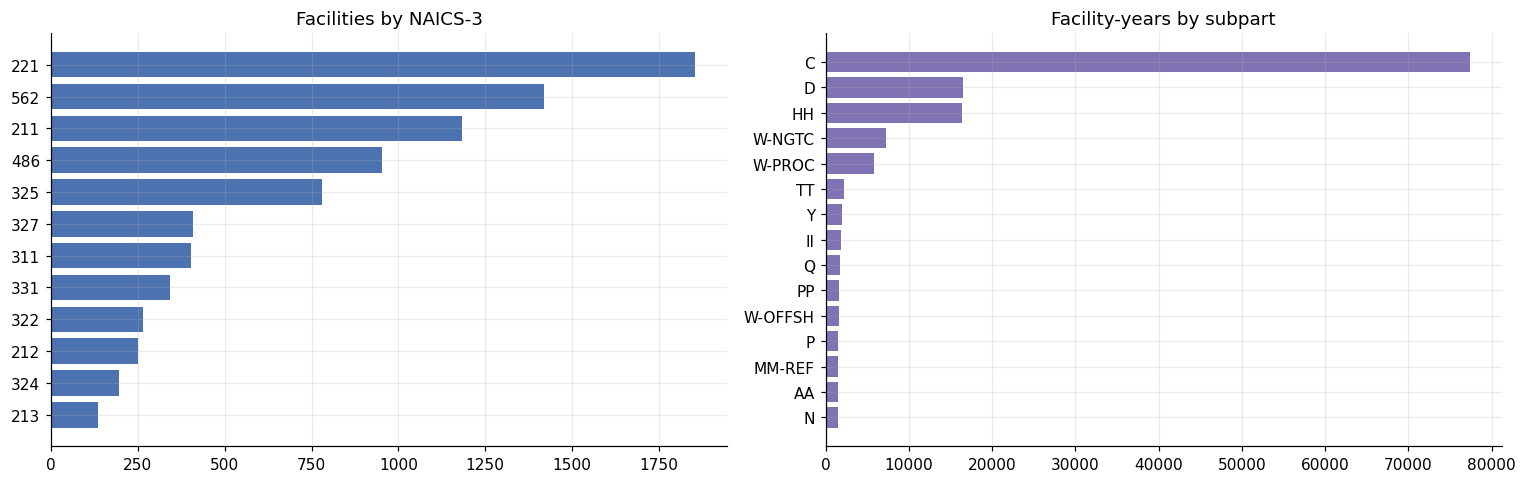


emissions distribution by sector -- who actually sits near the threshold:


,size,median,share_lt25k
naics3,,,
221,20554,246635.272,0.174
562,17413,54487.250,0.211
325,9151,85867.876,0.086
211,8926,50558.015,0.164
486,8670,39819.368,0.233
327,4843,94327.844,0.063
311,4605,44703.432,0.100
331,3838,73523.073,0.101
322,3178,112212.795,0.064


In [20]:
print("always-covered vs threshold-bound:")
display(de.groupby(["year","threshold_bound"]).FacilityId.nunique().unstack()
          .rename(columns={True:"threshold-bound", False:"always-covered"}))

top = de.groupby("naics3").FacilityId.nunique().sort_values(ascending=False).head(12)
sub = (de.subpart_set.explode().value_counts().head(15))

fig, ax = plt.subplots(1,2, figsize=(14,4.5))
ax[0].barh(top.index[::-1].astype(str), top.values[::-1], color="#4C72B0")
ax[0].set_title("Facilities by NAICS-3")
ax[1].barh(sub.index[::-1].astype(str), sub.values[::-1], color="#8172B3")
ax[1].set_title("Facility-years by subpart")
plt.tight_layout(); plt.savefig(OUT/"f7_composition.png", bbox_inches="tight"); plt.show()

print("\nemissions distribution by sector -- who actually sits near the threshold:")
display(de.groupby("naics3").emissions.agg(["size","median",
        lambda s:(s<25000).mean()]).rename(columns={"<lambda_0>":"share_lt25k"})
        .sort_values("size", ascending=False).head(12).round(3))

**What I take from this**

The threshold region is dominated by utilities, waste management, oil and gas, and pipelines —
which is also, not coincidentally, the composition of the 2015 exit wave. External validity
claims will have to be modest.

There is a second, less comfortable point. The facility-to-firm crosswalk I have been building
as an RA has its hardest unmatched cases concentrated in exactly these sectors — 31% waste
management, 17% oil and gas, Texas-heavy. So the facilities I cannot link to firms are
disproportionately the ones nearest the threshold. Any firm-level outcome would be estimated on
a selected sample. The facility-level work in this notebook is not subject to that, which is a
further reason to lead with it.

---
## 7 · Figure pack

In [21]:
from matplotlib.backends.backend_pdf import PdfPages
import glob
figs = sorted(glob.glob(str(OUT/"f*.png")))
print("figures written:"); [print("  ", f) for f in figs]
tab.to_csv(OUT/"t1_panel_by_year.csv")
print(f"\ntables written to {OUT}/")


figures written:
   output/f1_panel_structure.png
   output/f2_distribution.png
   output/f3_threshold_region.png
   output/f4_threshold_by_year.png
   output/f5_entry_exit.png
   output/f5b_cems.png
   output/f6_dynamics.png
   output/f7_composition.png
   output/f8_offramp_test.png
   output/fig1_tier3_diagnostics.png

tables written to output/


---
## Where this leaves me

Two of my three starting hypotheses did not survive:

| | What I expected | What I found |
|---|---|---|
| Bunching below 25,000 | excess mass | not identified — the sample is truncated at the cutoff |
| Bunching below 15,000 | excess mass at the 3-year off-ramp | density is smooth; no manipulation of levels |
| Exit responds to the rule | plausible | **yes, and sharply — 21.0% vs 1.5%** |

The surviving result is about *timing*, not levels. Facilities do not appear to manage emissions
in order to reach the off-ramp, but conditional on becoming eligible they leave at fourteen times
the base rate. That reframes the question from "what do firms do to escape disclosure" to "how
quickly do they take the exit once the rule allows it" — a weaker claim, but one the data
actually supports.

The sharper test of that — counting consecutive years below each threshold immediately before
exit, and looking for excess mass at exactly the statutory waiting periods of three and five
years — is in the accompanying memo, together with placebo thresholds and the oil-and-gas
robustness check.

**Open questions**

- Is exit *timing* enough to carry a paper on its own, or is it a first stage for something else?
- How would one map excess mass in *waiting time* into a cost? Kleven's chapter handles notches
  in a static density; I have not worked out whether the same logic transfers.
- The 2015 oil shock sits immediately before the June 2017 Paris withdrawal announcement, so
  whether a policy-shock layer survives is unresolved.
- Does TRI or NEI contain a comparable cessation provision? A second setting would make this a
  paper about disclosure thresholds generally rather than about one EPA rule.

**References**

- Tomar, S. (2023). Greenhouse Gas Disclosure and Emissions Benchmarking. *JAR* 61(2), 451–492.
- Kleven, H. (2016). Bunching. *Annual Review of Economics* 8, 435–464.
- 40 CFR 98.2(i) — cessation of reporting.